# Engine 1: Metabolic Profiler — Risk Prediction Model Training

**Project:** ML-Assisted Clinic Management System (G04)  
**Purpose:** Train two Random Forest classifiers to predict Diabetes and Heart Disease risk  
**Datasets:**
- Pima Indians Diabetes Database (768 rows, 9 columns)
- UCI Heart Disease Dataset — Full (920 rows, 16 columns)

**Output:** `.pkl` model files ready for FastAPI integration

---

## Notebook Structure

| Section | What It Does |
|---------|-------------|
| 1 | Install & import libraries |
| 2 | Load & explore both datasets |
| 3 | Clean & preprocess data |
| 4 | Train the Diabetes model |
| 5 | Train the Heart Disease model |
| 6 | Evaluate both models |
| 7 | Export `.pkl` files for FastAPI |
| 8 | Test with sample patient data |

## Section 1: Install & Import Libraries

In [ ]:
# Run this cell once to install dependencies (skip if already installed)
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [1]:
# ============================================================
# IMPORTS — everything we need for the entire notebook
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings

# Scikit-learn modules
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('All libraries imported successfully!')

All libraries imported successfully!


## Section 2: Load & Explore Both Datasets

**File locations (relative to this notebook in `ai-service/notebooks/`):**
- `../datasets/diabetes.csv`
- `../datasets/heart_disease_uci.csv`

In [2]:
# ============================================================
# CREATE MODELS FOLDER (if it doesn't exist)
# ============================================================
os.makedirs('../models', exist_ok=True)
print('models/ folder ready for saving trained models.')

models/ folder ready for saving trained models.


In [3]:
# ============================================================
# LOAD DIABETES DATASET (Pima Indians)
# ============================================================
# 768 rows, 9 columns
# 'Outcome' column: 0 = no diabetes, 1 = has diabetes
# Columns: Pregnancies, Glucose, BloodPressure, SkinThickness,
#          Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome

df_diabetes = pd.read_csv('../datasets/diabetes.csv')

print(f'Diabetes dataset shape: {df_diabetes.shape[0]} rows x {df_diabetes.shape[1]} columns')
print(f'\nColumns: {list(df_diabetes.columns)}')
print(f'\nTarget distribution:')
print(df_diabetes['Outcome'].value_counts())
print(f'\nDiabetes rate: {df_diabetes["Outcome"].mean()*100:.1f}%')
df_diabetes.head()

Diabetes dataset shape: 768 rows x 9 columns

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Diabetes rate: 34.9%


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# ============================================================
# LOAD HEART DISEASE DATASET (Full UCI — 920 rows)
# ============================================================
# YOUR dataset has:
#   - 920 rows, 16 columns
#   - Target column = 'num' (values 0,1,2,3,4)
#   - Extra columns: 'id', 'dataset' (hospital source)
#   - Several columns stored as object/string type
#   - 1,759 missing values across multiple columns
#
# We need to:
#   1. Drop 'id' and 'dataset' (not useful for prediction)
#   2. Rename 'num' to 'target'
#   3. Convert target to binary (0 vs 1-4)
#   4. Convert string columns to numeric
#   5. Handle the 1,759 missing values

df_heart = pd.read_csv('../datasets/heart_disease_uci.csv')

print(f'Heart disease dataset shape: {df_heart.shape[0]} rows x {df_heart.shape[1]} columns')
print(f'\nColumns: {list(df_heart.columns)}')
print(f'\nColumn data types:')
print(df_heart.dtypes)
print(f'\nTarget (num) distribution:')
print(df_heart['num'].value_counts().sort_index())
print(f'\nMissing values per column:')
print(df_heart.isnull().sum())
print(f'\nTotal missing values: {df_heart.isnull().sum().sum()}')
df_heart.head()

Heart disease dataset shape: 920 rows x 16 columns

Columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Column data types:
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

Target (num) distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Total missing values: 1759


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
# ============================================================
# STATISTICAL OVERVIEW OF BOTH DATASETS
# ============================================================

print('='*60)
print('DIABETES DATASET — Statistical Summary')
print('='*60)
print(df_diabetes.describe().round(2))
print(f'\nMissing values: {df_diabetes.isnull().sum().sum()}')

print('\n' + '='*60)
print('HEART DISEASE DATASET — Statistical Summary')
print('='*60)
print(df_heart.describe().round(2))
print(f'\nMissing values: {df_heart.isnull().sum().sum()}')

DIABETES DATASET — Statistical Summary
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.24     0.35  
std                        0.33   11.76     0.48  
min                        0.08   21.00     0.00  
25%

## Section 3: Clean & Preprocess Data

### Issues to fix:

**Diabetes dataset:**
- Has `0` values in columns where 0 is biologically impossible (Glucose, BloodPressure, BMI, etc.)
- These are missing values disguised as zeros

**Heart Disease dataset (major cleanup needed):**
- Drop `id` and `dataset` columns (not features)
- Rename `num` → `target` and convert to binary (0 vs 1+)
- Convert object/string columns to numeric
- Handle 1,759 missing values via median imputation
- Some columns (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `thal`) may be stored as strings

In [6]:
# ============================================================
# CLEAN DIABETES DATASET
# ============================================================
# Problem: Columns like Glucose, BloodPressure, BMI have 0 values
# A person CANNOT have 0 blood pressure and be alive!
# Solution: Replace 0s with NaN, then fill with column median
#
# WHY MEDIAN instead of MEAN?
# Median is resistant to outliers. If most people have Glucose ~120
# but one person has 999 (data entry error), mean gets pulled up
# but median stays accurate.

# These columns CANNOT logically be zero
zero_invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Count how many fake zeros exist BEFORE cleaning
print('Fake zeros found (before cleaning):')
for col in zero_invalid_cols:
    zero_count = (df_diabetes[col] == 0).sum()
    print(f'  {col}: {zero_count} zeros ({zero_count/len(df_diabetes)*100:.1f}%)')

# Replace 0s with NaN, then fill with median
df_diabetes_clean = df_diabetes.copy()
for col in zero_invalid_cols:
    df_diabetes_clean[col] = df_diabetes_clean[col].replace(0, np.nan)
    median_val = df_diabetes_clean[col].median()
    df_diabetes_clean[col] = df_diabetes_clean[col].fillna(median_val)

print(f'\nAfter cleaning — remaining NaN values: {df_diabetes_clean.isnull().sum().sum()}')
print('Diabetes dataset cleaned successfully!')

Fake zeros found (before cleaning):
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)

After cleaning — remaining NaN values: 0
Diabetes dataset cleaned successfully!


In [7]:
# ============================================================
# CLEAN HEART DISEASE DATASET (major cleanup)
# ============================================================
# Your dataset has 920 rows, 16 columns, 1759 missing values,
# target column 'num' with values 0-4, and extra columns id/dataset.

df_heart_clean = df_heart.copy()

# STEP 1: Drop non-feature columns
# 'id' is just a row identifier, 'dataset' is the hospital name
# Neither helps predict heart disease
df_heart_clean = df_heart_clean.drop(columns=['id', 'dataset'], errors='ignore')
print('Step 1: Dropped id and dataset columns')

# STEP 2: Rename 'num' to 'target' and convert to binary
# Original: 0=healthy, 1-4=varying severity of heart disease
# We convert: 0=healthy, 1=has heart disease (any severity)
df_heart_clean = df_heart_clean.rename(columns={'num': 'target'})
df_heart_clean['target'] = (df_heart_clean['target'] > 0).astype(int)
print(f'Step 2: Converted target to binary → {df_heart_clean["target"].value_counts().to_dict()}')

# STEP 3: Convert ALL feature columns to numeric
# Some columns (sex, cp, fbs, restecg, exang, slope, thal) are
# stored as object/string in the full UCI dataset.
# pd.to_numeric with errors='coerce' turns non-numeric strings into NaN
feature_cols = [c for c in df_heart_clean.columns if c != 'target']
for col in feature_cols:
    df_heart_clean[col] = pd.to_numeric(df_heart_clean[col], errors='coerce')
print(f'Step 3: Converted all columns to numeric')

# STEP 4: Check missing values after numeric conversion
print(f'\nMissing values per column after conversion:')
missing = df_heart_clean.isnull().sum()
print(missing[missing > 0])
print(f'Total missing: {missing.sum()}')

Step 1: Dropped id and dataset columns
Step 2: Converted target to binary → {1: 509, 0: 411}
Step 3: Converted all columns to numeric

Missing values per column after conversion:
sex         920
cp          920
trestbps     59
chol         30
fbs          90
restecg     920
thalch       55
exang        55
oldpeak      62
slope       920
ca          611
thal        920
dtype: int64
Total missing: 5562


In [8]:
# ============================================================
# STEP 5: Handle missing values in Heart Disease dataset
# ============================================================
# Strategy:
# - Columns with >60% missing → DROP (too unreliable)
# - Remaining columns → FILL with median
#
# We DON'T drop rows because with 1759 missing values spread
# across columns, dropping would lose too many rows.

print('Missing value rates:')
for col in df_heart_clean.columns:
    missing_count = df_heart_clean[col].isnull().sum()
    if missing_count > 0:
        rate = missing_count / len(df_heart_clean) * 100
        action = 'DROP COLUMN' if rate > 60 else 'FILL WITH MEDIAN'
        print(f'  {col:15s}: {missing_count:4d} missing ({rate:5.1f}%) → {action}')

# Drop columns with >60% missing (unreliable for training)
cols_to_drop = [
    col for col in df_heart_clean.columns
    if col != 'target' and df_heart_clean[col].isnull().sum() / len(df_heart_clean) > 0.60
]
if cols_to_drop:
    df_heart_clean = df_heart_clean.drop(columns=cols_to_drop)
    print(f'\nDropped high-missing columns: {cols_to_drop}')

# Fill remaining missing values with median
for col in df_heart_clean.columns:
    if col != 'target' and df_heart_clean[col].isnull().sum() > 0:
        median_val = df_heart_clean[col].median()
        df_heart_clean[col] = df_heart_clean[col].fillna(median_val)

print(f'\nAfter cleanup:')
print(f'  Shape: {df_heart_clean.shape}')
print(f'  Remaining missing values: {df_heart_clean.isnull().sum().sum()}')
print(f'  Columns: {list(df_heart_clean.columns)}')
print(f'\nHeart disease dataset cleaned successfully!')

Missing value rates:
  sex            :  920 missing (100.0%) → DROP COLUMN
  cp             :  920 missing (100.0%) → DROP COLUMN
  trestbps       :   59 missing (  6.4%) → FILL WITH MEDIAN
  chol           :   30 missing (  3.3%) → FILL WITH MEDIAN
  fbs            :   90 missing (  9.8%) → FILL WITH MEDIAN
  restecg        :  920 missing (100.0%) → DROP COLUMN
  thalch         :   55 missing (  6.0%) → FILL WITH MEDIAN
  exang          :   55 missing (  6.0%) → FILL WITH MEDIAN
  oldpeak        :   62 missing (  6.7%) → FILL WITH MEDIAN
  slope          :  920 missing (100.0%) → DROP COLUMN
  ca             :  611 missing ( 66.4%) → DROP COLUMN
  thal           :  920 missing (100.0%) → DROP COLUMN

Dropped high-missing columns: ['sex', 'cp', 'restecg', 'slope', 'ca', 'thal']

After cleanup:
  Shape: (920, 8)
  Remaining missing values: 0
  Columns: ['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'target']

Heart disease dataset cleaned successfully!


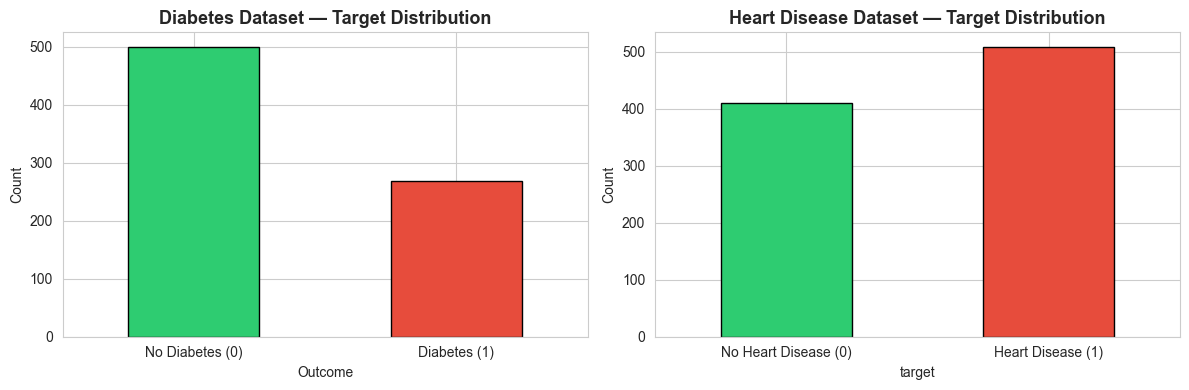

Chart saved to models/target_distribution.png


In [9]:
# ============================================================
# VISUALIZE: Target Distribution for Both Datasets
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Diabetes
colors = ['#2ecc71', '#e74c3c']
df_diabetes_clean['Outcome'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black'
)
axes[0].set_title('Diabetes Dataset — Target Distribution', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Heart Disease (using cleaned binary 'target' column)
df_heart_clean['target'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='black'
)
axes[1].set_title('Heart Disease Dataset — Target Distribution', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['No Heart Disease (0)', 'Heart Disease (1)'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../models/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to models/target_distribution.png')

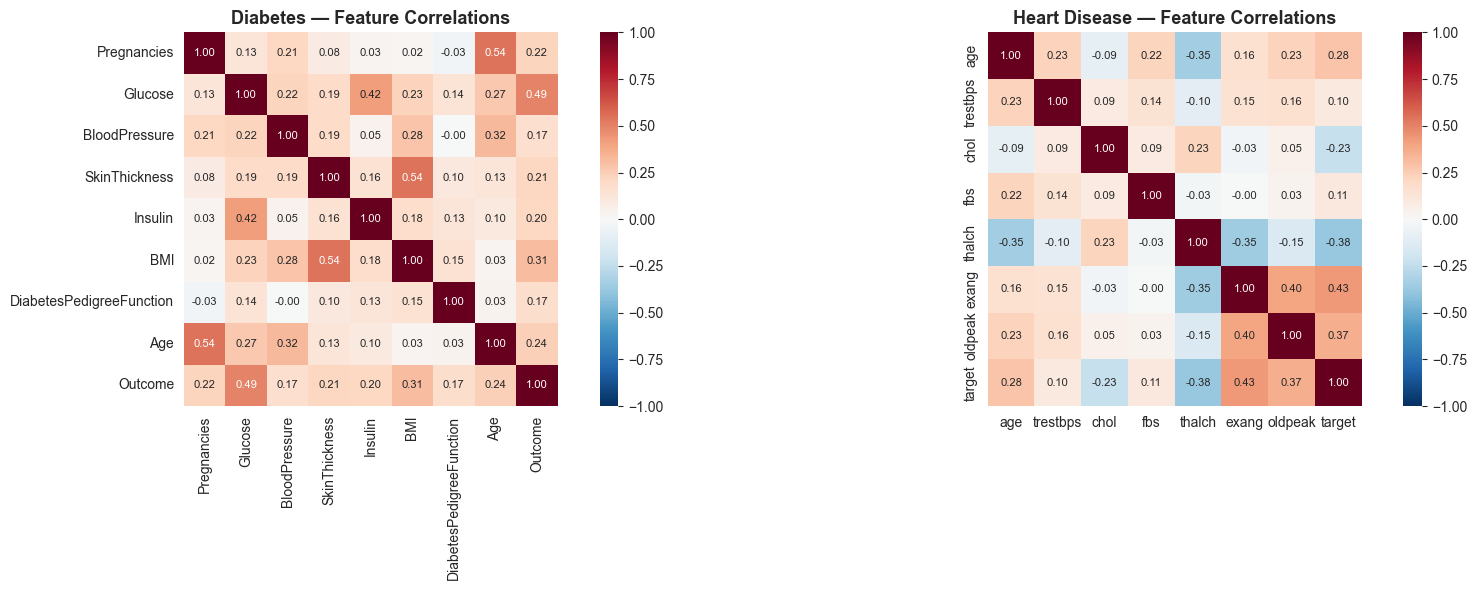

Chart saved to models/correlation_heatmaps.png


In [10]:
# ============================================================
# VISUALIZE: Correlation Heatmaps
# ============================================================
# Shows which features are most correlated with the target

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Diabetes correlations
corr_d = df_diabetes_clean.corr()
sns.heatmap(corr_d, annot=True, fmt='.2f', cmap='RdBu_r', ax=axes[0],
            vmin=-1, vmax=1, center=0, square=True, annot_kws={'size': 8})
axes[0].set_title('Diabetes — Feature Correlations', fontsize=13, fontweight='bold')

# Heart Disease correlations
corr_h = df_heart_clean.corr()
sns.heatmap(corr_h, annot=True, fmt='.2f', cmap='RdBu_r', ax=axes[1],
            vmin=-1, vmax=1, center=0, square=True, annot_kws={'size': 8})
axes[1].set_title('Heart Disease — Feature Correlations', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/correlation_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to models/correlation_heatmaps.png')

In [11]:
# ============================================================
# SELECT FEATURES & PREPARE FOR TRAINING
# ============================================================

# --- DIABETES MODEL ---
diabetes_feature_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]
X_diabetes = df_diabetes_clean[diabetes_feature_cols]
y_diabetes = df_diabetes_clean['Outcome']

print('DIABETES MODEL')
print(f'  Features ({len(diabetes_feature_cols)}): {diabetes_feature_cols}')
print(f'  Samples: {len(X_diabetes)}')
print(f'  Positive cases: {y_diabetes.sum()} ({y_diabetes.mean()*100:.1f}%)')

# --- HEART DISEASE MODEL ---
# Use ALL remaining features after cleanup (excluding 'target')
heart_feature_cols = [col for col in df_heart_clean.columns if col != 'target']
X_heart = df_heart_clean[heart_feature_cols]
y_heart = df_heart_clean['target']

print(f'\nHEART DISEASE MODEL')
print(f'  Features ({len(heart_feature_cols)}): {heart_feature_cols}')
print(f'  Samples: {len(X_heart)}')
print(f'  Positive cases: {y_heart.sum()} ({y_heart.mean()*100:.1f}%)')

DIABETES MODEL
  Features (8): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
  Samples: 768
  Positive cases: 268 (34.9%)

HEART DISEASE MODEL
  Features (7): ['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak']
  Samples: 920
  Positive cases: 509 (55.3%)


In [12]:
# ============================================================
# SPLIT DATA: 80% Training / 20% Testing
# ============================================================

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes, y_diabetes,
    test_size=0.2, random_state=42, stratify=y_diabetes
)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart,
    test_size=0.2, random_state=42, stratify=y_heart
)

print('Data split complete (80% train / 20% test)!')
print(f'\nDiabetes  → Train: {len(X_train_d)} | Test: {len(X_test_d)}')
print(f'Heart     → Train: {len(X_train_h)} | Test: {len(X_test_h)}')

Data split complete (80% train / 20% test)!

Diabetes  → Train: 614 | Test: 154
Heart     → Train: 736 | Test: 184


In [13]:
# ============================================================
# FEATURE SCALING (StandardScaler)
# ============================================================
# Converts every feature to mean=0, std=1
# IMPORTANT: fit on TRAINING only, then transform both

scaler_diabetes = StandardScaler()
X_train_d_scaled = scaler_diabetes.fit_transform(X_train_d)
X_test_d_scaled = scaler_diabetes.transform(X_test_d)

scaler_heart = StandardScaler()
X_train_h_scaled = scaler_heart.fit_transform(X_train_h)
X_test_h_scaled = scaler_heart.transform(X_test_h)

print('Feature scaling complete!')
print(f'Diabetes features scaled: {X_train_d_scaled.shape[1]}')
print(f'Heart disease features scaled: {X_train_h_scaled.shape[1]}')

Feature scaling complete!
Diabetes features scaled: 8
Heart disease features scaled: 7


## Section 4: Train the Diabetes Model

**Algorithm:** Random Forest Classifier (100 trees, majority vote)

In [14]:
# ============================================================
# TRAIN DIABETES RANDOM FOREST MODEL
# ============================================================

diabetes_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

diabetes_model.fit(X_train_d_scaled, y_train_d)

print('Diabetes model trained successfully!')
print(f'  Trees: {diabetes_model.n_estimators}')
print(f'  Training samples: {len(X_train_d_scaled)}')
print(f'  Features: {len(diabetes_feature_cols)}')

Diabetes model trained successfully!
  Trees: 100
  Training samples: 614
  Features: 8


In [15]:
# ============================================================
# CROSS-VALIDATION: Diabetes Model
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_d = cross_val_score(
    diabetes_model,
    scaler_diabetes.transform(X_diabetes),
    y_diabetes, cv=cv, scoring='accuracy'
)

print('Diabetes Model — 5-Fold Cross-Validation:')
print(f'  Fold accuracies: {[f"{s:.4f}" for s in cv_scores_d]}')
print(f'  Mean accuracy:   {cv_scores_d.mean():.4f} ± {cv_scores_d.std():.4f}')
print(f'  → Model is ~{cv_scores_d.mean()*100:.1f}% accurate on unseen data')

Diabetes Model — 5-Fold Cross-Validation:
  Fold accuracies: ['0.7987', '0.7662', '0.7857', '0.7908', '0.7190']
  Mean accuracy:   0.7721 ± 0.0286
  → Model is ~77.2% accurate on unseen data


## Section 5: Train the Heart Disease Model

In [16]:
# ============================================================
# TRAIN HEART DISEASE RANDOM FOREST MODEL
# ============================================================

heart_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

heart_model.fit(X_train_h_scaled, y_train_h)

print('Heart disease model trained successfully!')
print(f'  Trees: {heart_model.n_estimators}')
print(f'  Training samples: {len(X_train_h_scaled)}')
print(f'  Features: {len(heart_feature_cols)}')

Heart disease model trained successfully!
  Trees: 100
  Training samples: 736
  Features: 7


In [17]:
# ============================================================
# CROSS-VALIDATION: Heart Disease Model
# ============================================================

cv_scores_h = cross_val_score(
    heart_model,
    scaler_heart.transform(X_heart),
    y_heart, cv=cv, scoring='accuracy'
)

print('Heart Disease Model — 5-Fold Cross-Validation:')
print(f'  Fold accuracies: {[f"{s:.4f}" for s in cv_scores_h]}')
print(f'  Mean accuracy:   {cv_scores_h.mean():.4f} ± {cv_scores_h.std():.4f}')
print(f'  → Model is ~{cv_scores_h.mean()*100:.1f}% accurate on unseen data')

Heart Disease Model — 5-Fold Cross-Validation:
  Fold accuracies: ['0.7717', '0.8098', '0.7717', '0.7609', '0.8261']
  Mean accuracy:   0.7880 ± 0.0253
  → Model is ~78.8% accurate on unseen data


## Section 6: Evaluate Both Models

| Metric | What It Tells You |
|--------|-------------------|
| **Accuracy** | Overall % of correct predictions |
| **Precision** | When model says "High Risk", how often is it right? |
| **Recall** | Of all actual sick patients, how many did the model catch? |
| **F1-Score** | Balance between Precision and Recall |
| **AUC-ROC** | Discrimination ability (1.0 = perfect) |

In [18]:
# ============================================================
# EVALUATION HELPER FUNCTION
# ============================================================

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print(f'\n{"="*60}')
    print(f'{model_name} — TEST SET EVALUATION')
    print(f'{"="*60}')
    print(f'  Accuracy:  {acc:.4f}  ({acc*100:.1f}%)')
    print(f'  Precision: {prec:.4f}  (When it says sick, right {prec*100:.1f}% of the time)')
    print(f'  Recall:    {rec:.4f}  (Catches {rec*100:.1f}% of actual sick patients)')
    print(f'  F1-Score:  {f1:.4f}  (Balance of precision & recall)')
    print(f'  AUC-ROC:   {auc:.4f}  (Discrimination ability)')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Healthy', 'At Risk']))
    
    return y_pred, y_prob, {
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'auc': auc
    }

# Evaluate both models
y_pred_d, y_prob_d, metrics_d = evaluate_model(
    diabetes_model, X_test_d_scaled, y_test_d, 'DIABETES MODEL'
)
y_pred_h, y_prob_h, metrics_h = evaluate_model(
    heart_model, X_test_h_scaled, y_test_h, 'HEART DISEASE MODEL'
)


DIABETES MODEL — TEST SET EVALUATION
  Accuracy:  0.7403  (74.0%)
  Precision: 0.6296  (When it says sick, right 63.0% of the time)
  Recall:    0.6296  (Catches 63.0% of actual sick patients)
  F1-Score:  0.6296  (Balance of precision & recall)
  AUC-ROC:   0.8265  (Discrimination ability)

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.80      0.80      0.80       100
     At Risk       0.63      0.63      0.63        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154


HEART DISEASE MODEL — TEST SET EVALUATION
  Accuracy:  0.7880  (78.8%)
  Precision: 0.8119  (When it says sick, right 81.2% of the time)
  Recall:    0.8039  (Catches 80.4% of actual sick patients)
  F1-Score:  0.8079  (Balance of precision & recall)
  AUC-ROC:   0.8575  (Discrimination ability)

Classification Report:
              precision    recall 

In [ ]:
# ============================================================
# VISUALIZE: Confusion Matrices
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_test, y_pred, title in [
    (axes[0], y_test_d, y_pred_d, 'Diabetes Model'),
    (axes[1], y_test_h, y_pred_h, 'Heart Disease Model')
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Healthy', 'At Risk'],
        yticklabels=['Healthy', 'At Risk'],
        annot_kws={'size': 16}
    )
    ax.set_title(f'{title} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../models/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to models/confusion_matrices.png')

In [ ]:
# ============================================================
# VISUALIZE: ROC Curves
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

fpr_d, tpr_d, _ = roc_curve(y_test_d, y_prob_d)
ax.plot(fpr_d, tpr_d, label=f'Diabetes (AUC = {metrics_d["auc"]:.3f})',
        color='#3498db', linewidth=2)

fpr_h, tpr_h, _ = roc_curve(y_test_h, y_prob_h)
ax.plot(fpr_h, tpr_h, label=f'Heart Disease (AUC = {metrics_h["auc"]:.3f})',
        color='#e74c3c', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Chance (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Both Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to models/roc_curves.png')

In [ ]:
# ============================================================
# VISUALIZE: Feature Importance
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Diabetes
feat_imp_d = pd.Series(
    diabetes_model.feature_importances_, index=diabetes_feature_cols
).sort_values(ascending=True)
feat_imp_d.plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Diabetes — Feature Importance', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Heart Disease
feat_imp_h = pd.Series(
    heart_model.feature_importances_, index=heart_feature_cols
).sort_values(ascending=True)
feat_imp_h.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Heart Disease — Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to models/feature_importance.png')

## Section 7: Export `.pkl` Files for FastAPI

Files saved to `ai-service/models/`:

| File | Purpose |
|------|--------|
| `diabetes_model.pkl` | Trained diabetes Random Forest |
| `heart_model.pkl` | Trained heart disease Random Forest |
| `diabetes_scaler.pkl` | Scales patient data for diabetes model |
| `heart_scaler.pkl` | Scales patient data for heart model |
| `model_metadata.json` | Feature names, metrics, training info |

In [ ]:
# ============================================================
# SAVE MODELS AND SCALERS
# ============================================================

joblib.dump(diabetes_model, '../models/diabetes_model.pkl')
joblib.dump(scaler_diabetes, '../models/diabetes_scaler.pkl')
print('Saved: models/diabetes_model.pkl')
print('Saved: models/diabetes_scaler.pkl')

joblib.dump(heart_model, '../models/heart_model.pkl')
joblib.dump(scaler_heart, '../models/heart_scaler.pkl')
print('Saved: models/heart_model.pkl')
print('Saved: models/heart_scaler.pkl')

In [ ]:
# ============================================================
# SAVE MODEL METADATA
# ============================================================

from datetime import datetime

metadata = {
    'trained_at': datetime.now().isoformat(),
    'diabetes_model': {
        'algorithm': 'RandomForestClassifier',
        'n_estimators': 100,
        'features': diabetes_feature_cols,
        'training_samples': len(X_train_d),
        'test_samples': len(X_test_d),
        'metrics': {
            'accuracy': round(metrics_d['accuracy'], 4),
            'precision': round(metrics_d['precision'], 4),
            'recall': round(metrics_d['recall'], 4),
            'f1_score': round(metrics_d['f1'], 4),
            'auc_roc': round(metrics_d['auc'], 4),
            'cv_mean_accuracy': round(float(cv_scores_d.mean()), 4),
        },
        'dataset': 'Pima Indians Diabetes Database (768 records)'
    },
    'heart_model': {
        'algorithm': 'RandomForestClassifier',
        'n_estimators': 100,
        'features': heart_feature_cols,
        'training_samples': len(X_train_h),
        'test_samples': len(X_test_h),
        'metrics': {
            'accuracy': round(metrics_h['accuracy'], 4),
            'precision': round(metrics_h['precision'], 4),
            'recall': round(metrics_h['recall'], 4),
            'f1_score': round(metrics_h['f1'], 4),
            'auc_roc': round(metrics_h['auc'], 4),
            'cv_mean_accuracy': round(float(cv_scores_h.mean()), 4),
        },
        'dataset': 'UCI Heart Disease - Full (920 records)'
    }
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: models/model_metadata.json')
print(json.dumps(metadata, indent=2))

In [ ]:
# ============================================================
# VERIFY: List all saved files
# ============================================================

print('\nAll files in models/ folder:')
print('-' * 50)
models_dir = '../models'
for f in sorted(os.listdir(models_dir)):
    size = os.path.getsize(os.path.join(models_dir, f))
    if size > 1024*1024:
        print(f'  {f:45s} {size/1024/1024:.1f} MB')
    else:
        print(f'  {f:45s} {size/1024:.1f} KB')

print('\nAll model artifacts saved and ready for FastAPI!')

## Section 8: Test with Sample Patient Data

Simulates a patient filling out the health screening form in React.

In [ ]:
# ============================================================
# PREDICTION FUNCTION (will be copied to FastAPI app.py)
# ============================================================

def predict_risk(age, gender, bmi, blood_pressure, glucose, cholesterol):
    """
    Takes patient vitals from the health screening form and
    returns a combined risk assessment.
    
    Parameters:
        age (int): Patient's age
        gender (int): 0 = female, 1 = male
        bmi (float): Body Mass Index
        blood_pressure (int): Systolic BP (mmHg)
        glucose (int): Fasting glucose (mg/dL)
        cholesterol (int): Total cholesterol (mg/dL)
    
    Returns:
        dict with risk_level, confidence, reasons, per-disease details
    """
    
    # ---- DIABETES PREDICTION ----
    diabetes_input = pd.DataFrame([{
        'Pregnancies': 0,
        'Glucose': glucose,
        'BloodPressure': blood_pressure,
        'SkinThickness': 29,                    # dataset median
        'Insulin': 125,                         # dataset median
        'BMI': bmi,
        'DiabetesPedigreeFunction': 0.3725,     # dataset median
        'Age': age
    }])
    
    diabetes_input_scaled = scaler_diabetes.transform(diabetes_input)
    diabetes_prob = diabetes_model.predict_proba(diabetes_input_scaled)[0][1]
    
    # ---- HEART DISEASE PREDICTION ----
    # Build input dynamically based on which features survived cleanup
    heart_defaults = {
        'age': age,
        'sex': gender,
        'cp': 0,
        'trestbps': blood_pressure,
        'chol': cholesterol,
        'fbs': 1 if glucose > 120 else 0,
        'restecg': 0,
        'thalach': 150,
        'exang': 0,
        'oldpeak': 0,
        'slope': 1,
        'ca': 0,
        'thal': 2
    }
    
    # Only include features that the model actually uses
    # (some columns may have been dropped due to high missing rates)
    heart_input_dict = {col: heart_defaults.get(col, 0) for col in heart_feature_cols}
    heart_input = pd.DataFrame([heart_input_dict])
    
    heart_input_scaled = scaler_heart.transform(heart_input)
    heart_prob = heart_model.predict_proba(heart_input_scaled)[0][1]
    
    # ---- COMBINE RESULTS ----
    max_prob = max(diabetes_prob, heart_prob)
    
    if max_prob >= 0.7:
        risk_level = 'High'
    elif max_prob >= 0.4:
        risk_level = 'Medium'
    else:
        risk_level = 'Low'
    
    # Build reasons list
    reasons = []
    if diabetes_prob >= 0.5:
        reasons.append(f'Elevated diabetes risk ({diabetes_prob*100:.0f}% probability)')
    if heart_prob >= 0.5:
        reasons.append(f'Elevated heart disease risk ({heart_prob*100:.0f}% probability)')
    if glucose > 140:
        reasons.append('High glucose level')
    if blood_pressure > 140:
        reasons.append('High blood pressure')
    if bmi > 30:
        reasons.append('BMI indicates obesity')
    if cholesterol > 240:
        reasons.append('High cholesterol')
    if not reasons:
        reasons.append('All vitals within acceptable range')
    
    return {
        'risk_level': risk_level,
        'confidence': round(float(max_prob), 4),
        'reasons': reasons,
        'diabetes': {
            'probability': round(float(diabetes_prob), 4),
            'risk': 'High' if diabetes_prob >= 0.7 else ('Medium' if diabetes_prob >= 0.4 else 'Low')
        },
        'heart_disease': {
            'probability': round(float(heart_prob), 4),
            'risk': 'High' if heart_prob >= 0.7 else ('Medium' if heart_prob >= 0.4 else 'Low')
        },
        'disclaimer': 'This is an AI-based risk estimation for triage support only. It does NOT replace professional medical diagnosis.'
    }

print('predict_risk() function ready for testing!')

In [ ]:
# ============================================================
# TEST CASE 1: Healthy patient (expect LOW risk)
# ============================================================

result = predict_risk(
    age=28, gender=0, bmi=22.5,
    blood_pressure=118, glucose=85, cholesterol=190
)

print('TEST CASE 1: Healthy 28-year-old female')
print(json.dumps(result, indent=2))

In [ ]:
# ============================================================
# TEST CASE 2: High-risk patient (expect HIGH risk)
# ============================================================

result = predict_risk(
    age=58, gender=1, bmi=34.5,
    blood_pressure=155, glucose=180, cholesterol=280
)

print('TEST CASE 2: High-risk 58-year-old male')
print(json.dumps(result, indent=2))

In [ ]:
# ============================================================
# TEST CASE 3: Borderline patient (expect MEDIUM risk)
# ============================================================

result = predict_risk(
    age=45, gender=1, bmi=28.0,
    blood_pressure=135, glucose=130, cholesterol=220
)

print('TEST CASE 3: Borderline 45-year-old male')
print(json.dumps(result, indent=2))

In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print('='*60)
print('TRAINING COMPLETE — FINAL SUMMARY')
print('='*60)
print(f'\nDiabetes Model:')
print(f'  Dataset:     Pima Indians ({len(df_diabetes)} rows)')
print(f'  Features:    {len(diabetes_feature_cols)}')
print(f'  Accuracy:    {metrics_d["accuracy"]*100:.1f}%')
print(f'  AUC-ROC:     {metrics_d["auc"]:.3f}')
print(f'  CV Accuracy: {cv_scores_d.mean()*100:.1f}% ± {cv_scores_d.std()*100:.1f}%')

print(f'\nHeart Disease Model:')
print(f'  Dataset:     UCI Full ({len(df_heart)} rows)')
print(f'  Features:    {len(heart_feature_cols)}')
print(f'  Accuracy:    {metrics_h["accuracy"]*100:.1f}%')
print(f'  AUC-ROC:     {metrics_h["auc"]:.3f}')
print(f'  CV Accuracy: {cv_scores_h.mean()*100:.1f}% ± {cv_scores_h.std()*100:.1f}%')

print(f'\nFiles saved to models/:')
for f in sorted(os.listdir('../models')):
    print(f'  {f}')

print(f'\nNext step: Build the FastAPI POST /predict-risk endpoint.')

---

## What Changed From the Previous Notebook

| Issue | Old Notebook | This Notebook |
|-------|-------------|---------------|
| Heart target column | Used `target` | Uses `num` → renamed to `target` |
| Heart dataset size | Expected 303 rows | Handles 920-row full UCI dataset |
| Extra columns | Not handled | Drops `id` and `dataset` |
| Missing values | Simple dropna | 1,759 values: median imputation + column dropping for >60% missing |
| String columns | Not handled | Converts object columns to numeric with `pd.to_numeric(errors='coerce')` |
| Target encoding | Assumed binary | Converts 0-4 scale to binary (0 vs 1+) |
| File paths | `models/` | `../models/` (notebook is in `notebooks/` subfolder) |
| Bonus | — | Added correlation heatmaps visualization |